In [1]:
import wandb
from collections import defaultdict
import math
from matplotlib import pyplot as plt
import numpy as np
api = wandb.Api()

In [2]:
api = wandb.Api()
runs = api.runs("huzican/div") 
for run in runs:
    if run.name in ['rs_equ_all_100step','rs_pos_rs_0.1-neg_rs_0.01-equ_0.68+belu_0.08_error','rs_struct_all_0.1_len_penalty2000_repetition_penalty']:
        print(f"名称: {run.name}, ID: {run.id}")

名称: rs_equ_all_100step, ID: 38coclag
名称: rs_pos_rs_0.1-neg_rs_0.01-equ_0.68+belu_0.08_error, ID: xjp4rakc
名称: rs_struct_all_0.1_len_penalty2000_repetition_penalty, ID: ej9caryj


In [3]:
def smooth(y, radius, mode='two_sided', valid_only=False):
    assert mode in ('two_sided', 'causal')
    if len(y) < 2*radius+1:
        return np.ones_like(y) * y.mean()
    elif mode == 'two_sided':
        convkernel = np.ones(2 * radius+1)
        out = np.convolve(y, convkernel,mode='same') / np.convolve(np.ones_like(y), convkernel, mode='same')
        if valid_only:
            out[:radius] = out[-radius:] = np.nan
    elif mode == 'causal':
        convkernel = np.ones(radius)
        out = np.convolve(y, convkernel,mode='full') / np.convolve(np.ones_like(y), convkernel, mode='full')
        out = out[:-radius+1]
        if valid_only:
            out[:radius] = np.nan
    return out

In [6]:
run_names = ["huzican/div/4uxneja0","huzican/div/xjp4rakc","huzican/div/38coclag","huzican/div/ej9caryj"]
legends = ["Correct","Error","All","All w/ length penalty"]
metrics = ["Test Score","Training Accuracy","Response Length"]
paths = ["val/test_score/average", "critic/score/mean", "response_length/mean"]

run_results = {}
for idx, run_name in enumerate(run_names):
    run = api.run(run_name)
    scores = defaultdict(list)
    # print(scores)
    for i, row in run.history().iterrows():
        # print(row['val/test_score/aime'])
        # print(row['val/test_score/math'])
        # for path in paths:
        #     if not math.isnan(row[path]):
        #         scores[benchmark].append(row[path])
        for j, path in enumerate(paths):
            if not math.isnan(row[path]):
                scores[metrics[j]].append(row[path])
        # if not math.isnan(row['batch/solve_all']):
        #     scores["solve_all"].append(row['batch/solve_all'])
        # if not math.isnan(row['batch/solve_none']):
        #     scores["solve_none"].append(row['batch/solve_none'])
    
    run_results[legends[idx]] = scores
print(run_results.keys())

dict_keys(['Correct', 'Error', 'All', 'All w/ length penalty'])


/tmp/ipykernel_102118/2847385749.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


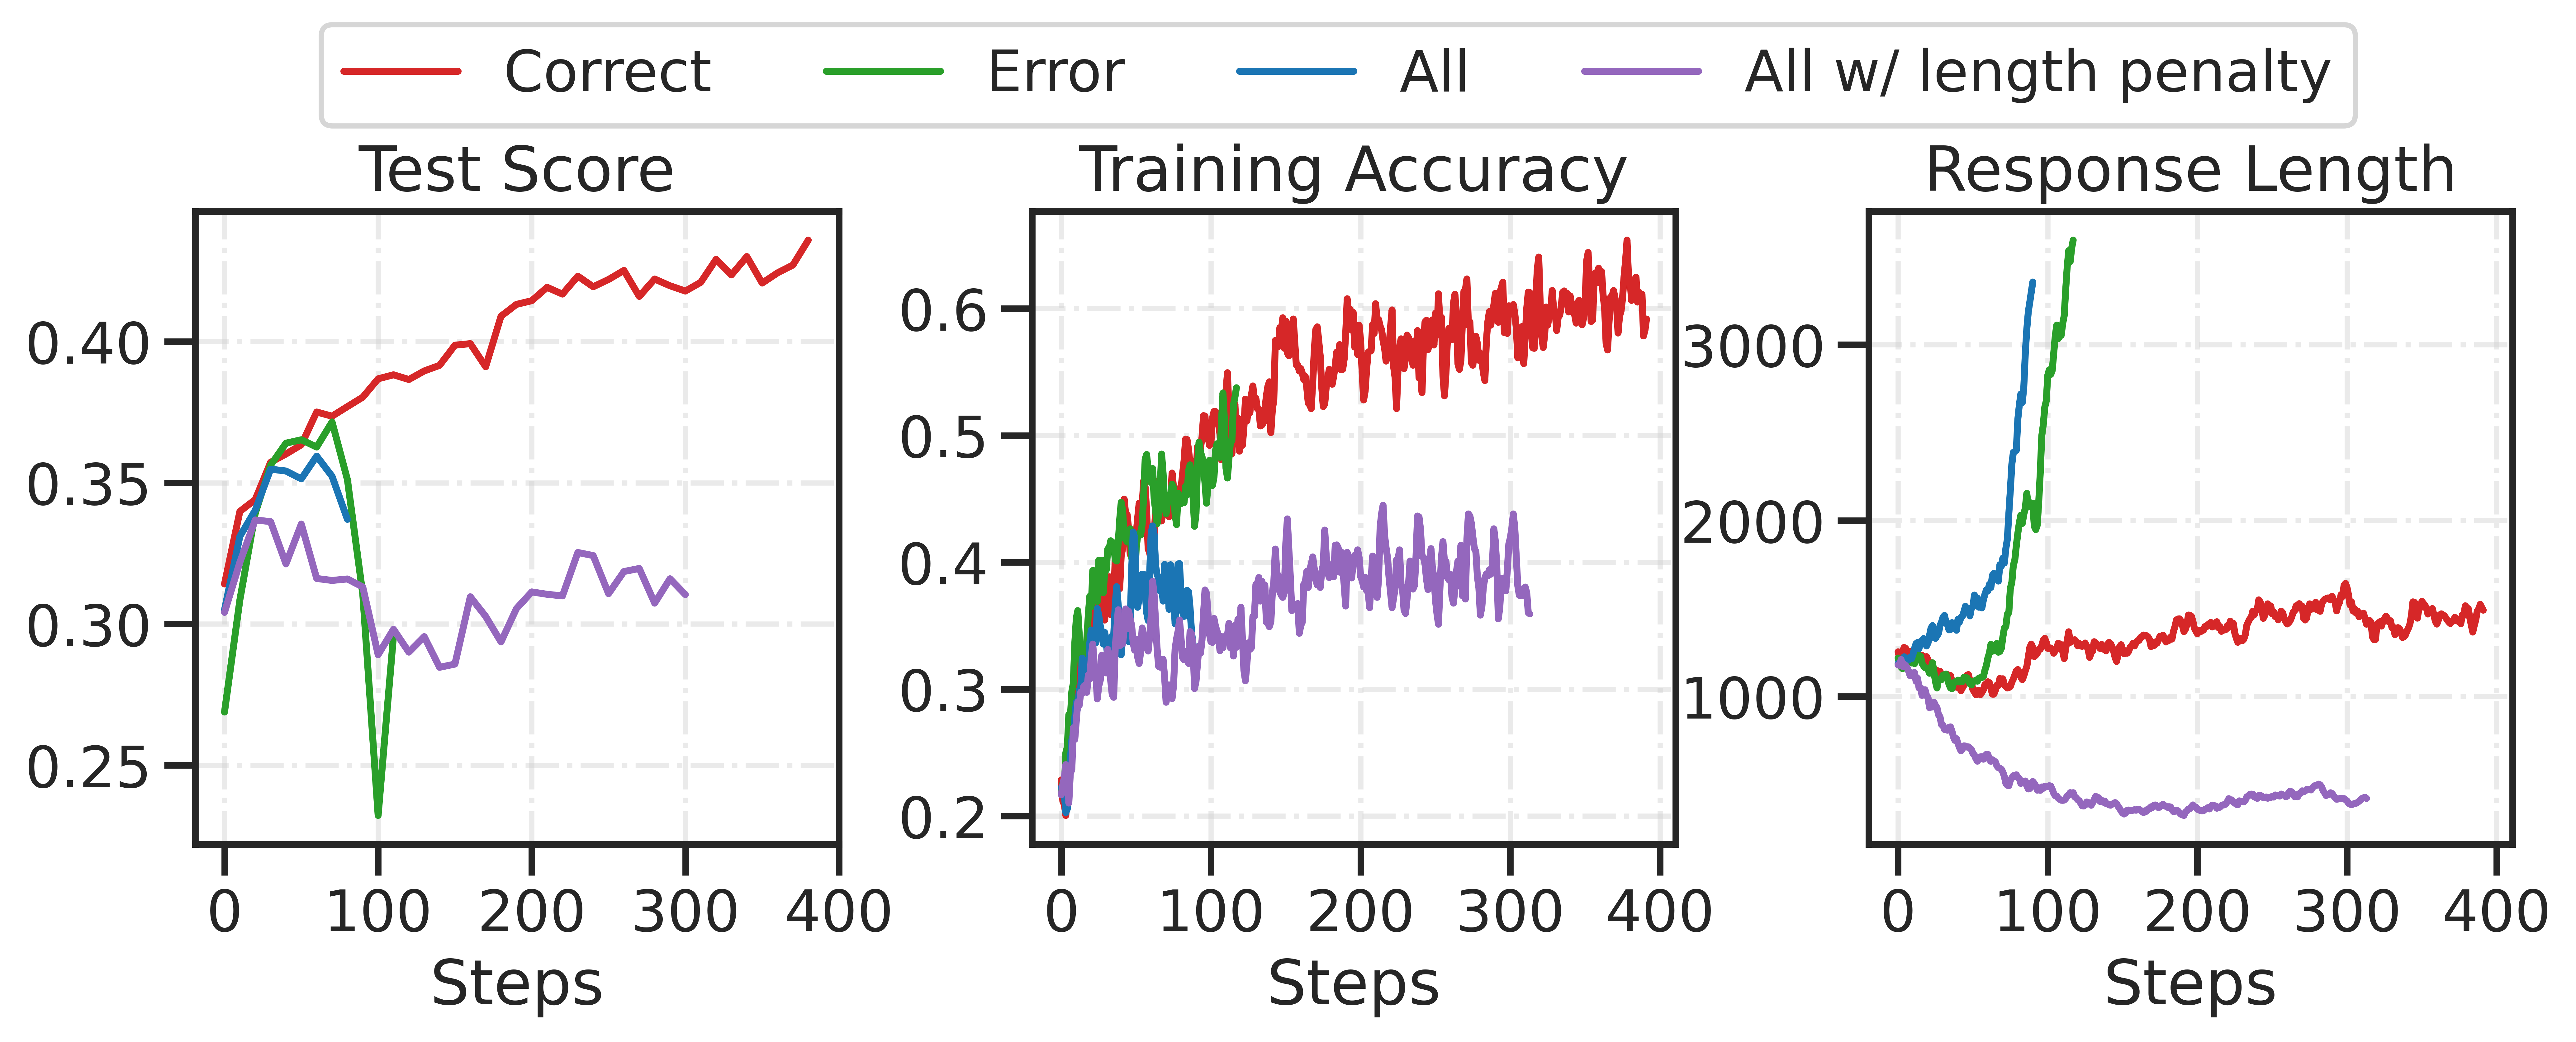

In [24]:
color = ['#D62728','#2A9F2A', '#1B75B4','#9467BD','#7F7F7F','#E377C2','#FF7F0E']

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('ticks')
sns.set_context('talk')
fig = plt.figure(figsize=(12, 3.3), dpi=800)
Grid = plt.GridSpec(1, 3, wspace=0.3, hspace=0.35)
# plt.rcParams.update({'font.size': 25})
for sub_i, metric in enumerate(metrics):
    sub_ax = plt.subplot(Grid[sub_i//3,sub_i%3])
    plt.title(f'{metric}',fontsize=18)
    for index, alg in enumerate(legends):
        data = np.array(run_results[alg][metric])
        if metric in ['Test Score']:
            x_step = np.array(range(data.shape[0]))*10
        else:
            data = smooth(data,1)
            x_step = np.array(range(data.shape[0]))
        ax = sns.lineplot(x=x_step, y=data.flatten(),label=legends[index], color=color[index], linewidth=2)
        # sub_ax.legend_.remove()
    plt.grid(True,linestyle='-.',alpha=0.4)
        # plt.legend(fontsize = 10,loc='lower right')
        # plt.ylabel('Sample Numbers', labelpad=-0.5)
    plt.xlabel('Steps')
    plt.xticks(np.array(range(0, 401,100)))
    handles, labels = sub_ax.get_legend_handles_labels()
    sub_ax.legend_.remove()
plt.legend(handles, labels, ncol=4, bbox_to_anchor=(0.8, 1.34))
plt.tight_layout()
plt.savefig('./reward_hacking.pdf',bbox_inches='tight')